# Decision Boundary Visualization

Train an MLP on a non-linear dataset and visualize decision boundary.

## Concepts
- Non-linear classification
- Model generalization
- Visualization

In [18]:
import numpy as np
from src.utils import make_moons_dataset, plot_decision_boundary
from src.nn import MLP

## Dataset

In [19]:
X, y = make_moons_dataset(200, noise=0.2)

## Model

In [20]:
model = MLP(2, [16, 16, 1], activation='tanh')
# Model: 2 Inputs -> Two Hidden Layers (16 neurons) -> 1 Output Neuron

## Training

In [21]:
learning_rate = 0.01

for epoch in range(51):
    total_loss = 0

    for xi, yi in zip(X, y):
        # Reset parameters before calculating forward/backward pass
        model.zero_grad()

        # Forward pass
        pred = model(list(xi))
        
        # Loss expression
        loss = (pred - yi)**2

        # Backward pass
        loss.backward()

        # Update weights (SGD optimization step)
        for p in model.parameters():
            p.data -= learning_rate * p.grad

        total_loss += loss.data
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {total_loss:.4f}")

Epoch 0: Loss 102.7752
Epoch 10: Loss 40.3849
Epoch 20: Loss 36.0911
Epoch 30: Loss 34.1318
Epoch 40: Loss 32.0371
Epoch 50: Loss 31.0638


## Visualization

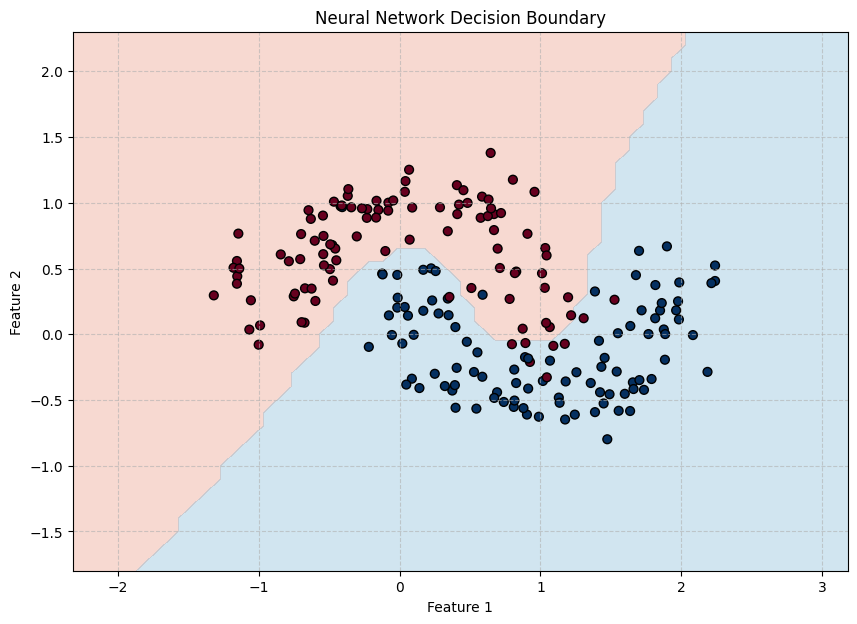

In [22]:
plot_decision_boundary(model, X, y)